In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

os.makedirs('images', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# -------------------------------------------------------
# Load HAR dataset
# Dataset folder structure expected:
#   dataset/UCI HAR Dataset/
#       train/X_train.txt, y_train.txt
#       test/X_test.txt,  y_test.txt
#       features.txt
#       activity_labels.txt
# -------------------------------------------------------
base = 'dataset/UCI HAR Dataset/'

features  = pd.read_csv(base + 'features.txt', sep='\\s+', header=None, names=['idx', 'name'])
act_labels = pd.read_csv(base + 'activity_labels.txt', sep='\\s+', header=None, names=['id', 'activity'])

X_train = pd.read_csv(base + 'train/X_train.txt', sep='\\s+', header=None)
y_train = pd.read_csv(base + 'train/y_train.txt', sep='\\s+', header=None, names=['label'])

X_test  = pd.read_csv(base + 'test/X_test.txt',  sep='\\s+', header=None)
y_test  = pd.read_csv(base + 'test/y_test.txt',  sep='\\s+', header=None, names=['label'])

# Concatenate train + test
X = pd.concat([X_train, X_test], axis=0, ignore_index=True)
y = pd.concat([y_train, y_test], axis=0, ignore_index=True)['label']

# Assign feature names
X.columns = features['name'].values

# Map integer labels to activity names
label_map = dict(zip(act_labels['id'], act_labels['activity']))
y_named   = y.map(label_map)

print('Dataset Shape:', X.shape)
print('Label Distribution:')
print(y_named.value_counts())

Dataset Shape: (10299, 561)
Label Distribution:
label
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


In [3]:
# Check for missing values
print('Missing values:', X.isnull().sum().sum())
print('Data types:', X.dtypes.value_counts().to_dict())

Missing values: 0
Data types: {dtype('float64'): 561}


In [4]:
# Standardize features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Standardized shape:', X_scaled.shape)

Standardized shape: (10299, 561)


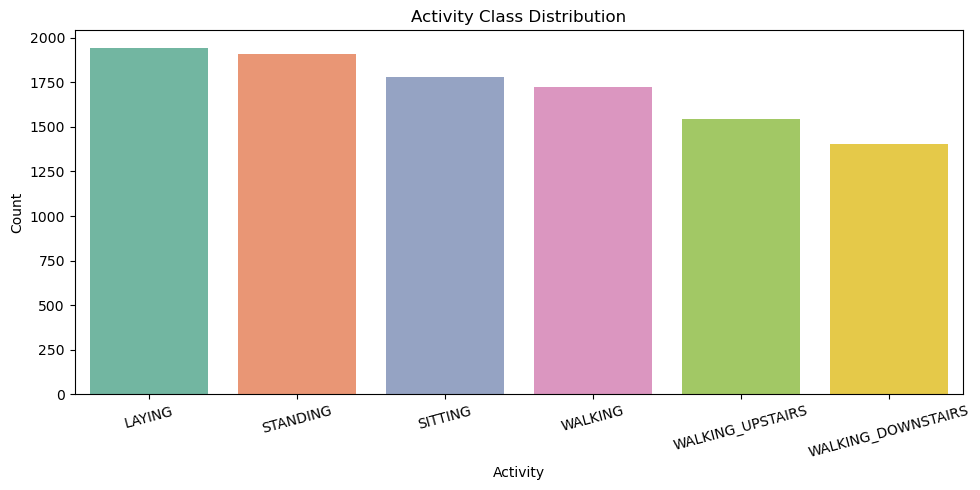

In [5]:
# Activity distribution bar chart
plt.figure(figsize=(10, 5))
order = y_named.value_counts().index
sns.countplot(x=y_named, order=order, palette='Set2')
plt.title('Activity Class Distribution')
plt.xlabel('Activity')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('images/activity_distribution.png', dpi=300)
plt.show()

In [6]:
# PCA to 2D for visualization
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
print(f'PCA 2D explained variance: {np.sum(pca2.explained_variance_ratio_)*100:.2f}%')

PCA 2D explained variance: 56.98%


In [7]:
# t-SNE to 2D for visualization (use PCA 50D as input for speed)
pca50 = PCA(n_components=50, random_state=42)
X_pca50 = pca50.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=40)
X_tsne = tsne.fit_transform(X_pca50)
print('t-SNE done.')

t-SNE done.


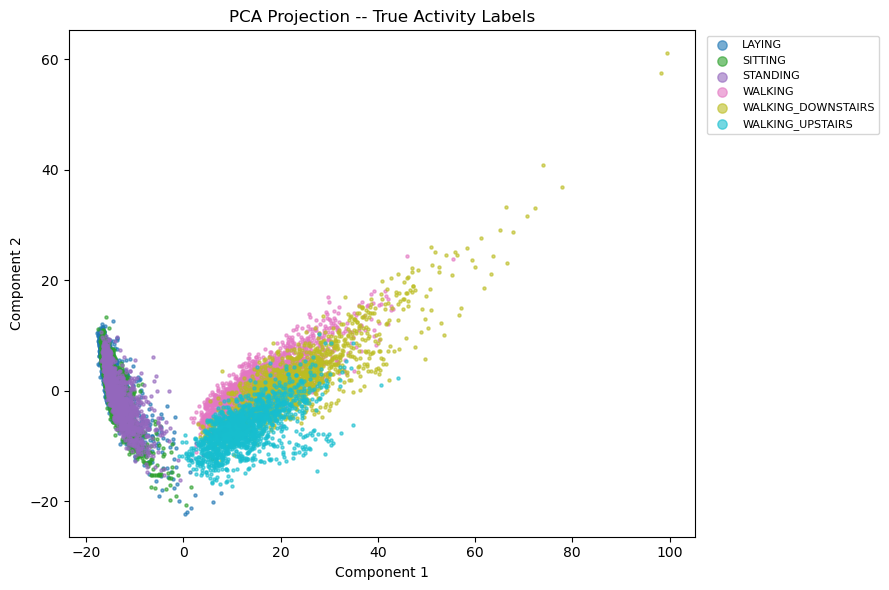

In [8]:
# Helper: scatter plot with legend
def scatter_2d(coords, labels, title, save_path, cmap='tab10'):
    unique_labels = np.unique(labels)
    colors = plt.cm.get_cmap(cmap, len(unique_labels))
    plt.figure(figsize=(9, 6))
    for i, lbl in enumerate(unique_labels):
        mask = labels == lbl
        plt.scatter(coords[mask, 0], coords[mask, 1],
                    s=5, alpha=0.6, color=colors(i), label=str(lbl))
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

# True labels - PCA
scatter_2d(X_pca2, y_named.values,
           'PCA Projection -- True Activity Labels',
           'images/pca_true_labels.png')

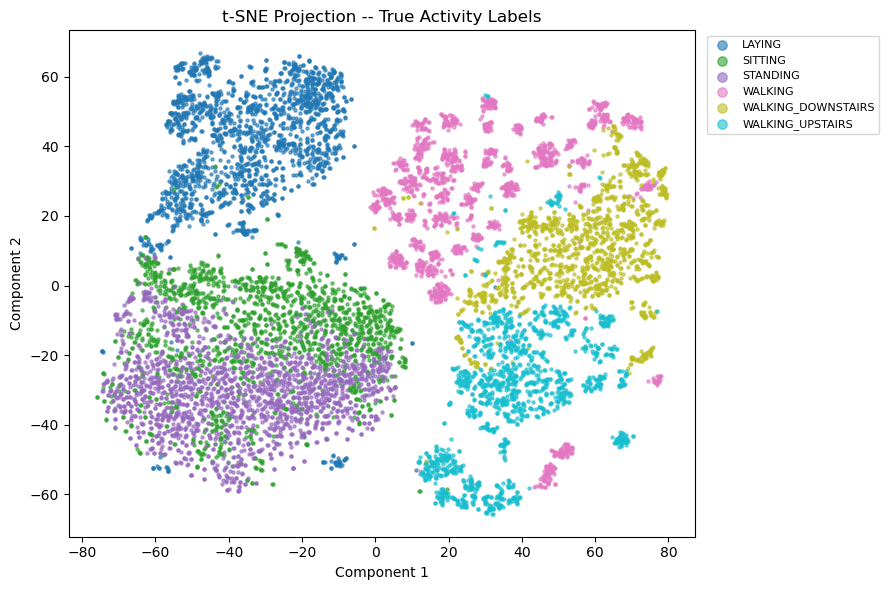

In [9]:
# True labels - t-SNE
scatter_2d(X_tsne, y_named.values,
           't-SNE Projection -- True Activity Labels',
           'images/tsne_true_labels.png')

In [10]:
# -------------------------------------------------------
# K-Means: Elbow Method + Silhouette
# -------------------------------------------------------
# Use a 20% sample for speed during hyperparameter search
from sklearn.utils import resample

X_sample, y_sample = resample(X_scaled, y.values, n_samples=3000, random_state=42)

k_range = range(2, 9)
wcss_list, sil_list = [], []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_sample)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_sample, km.labels_, sample_size=2000, random_state=42))
    print(f'k={k}  WCSS={km.inertia_:.2f}  Silhouette={sil_list[-1]:.4f}')

k=2  WCSS=940338.75  Silhouette=0.3945
k=3  WCSS=839955.35  Silhouette=0.3139
k=4  WCSS=797965.60  Silhouette=0.1501
k=5  WCSS=761293.51  Silhouette=0.1386
k=6  WCSS=736950.81  Silhouette=0.1248
k=7  WCSS=718981.15  Silhouette=0.0900
k=8  WCSS=703021.71  Silhouette=0.0902


In [11]:
# Elbow + Silhouette tables
elbow_df = pd.DataFrame({
    'k': list(k_range),
    'WCSS (Inertia)': wcss_list,
    'Silhouette Score': sil_list
})
print(elbow_df.to_string(index=False))

 k  WCSS (Inertia)  Silhouette Score
 2   940338.748578          0.394534
 3   839955.351468          0.313945
 4   797965.598404          0.150071
 5   761293.505244          0.138550
 6   736950.814862          0.124800
 7   718981.147177          0.089972
 8   703021.714202          0.090158


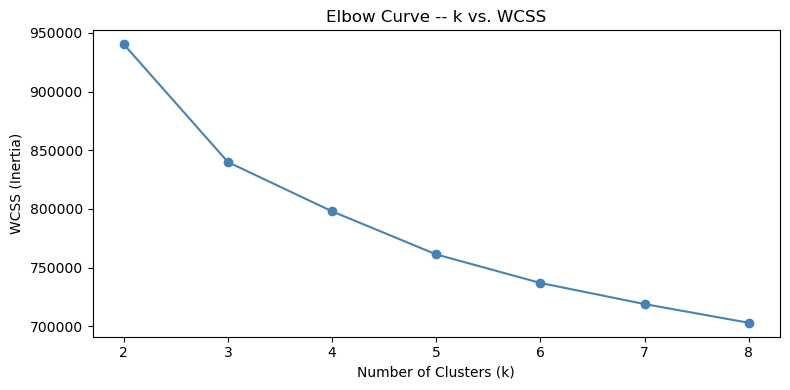

In [12]:
# Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), wcss_list, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Curve -- k vs. WCSS')
plt.tight_layout()
plt.savefig('images/elbow_curve.png', dpi=300)
plt.show()

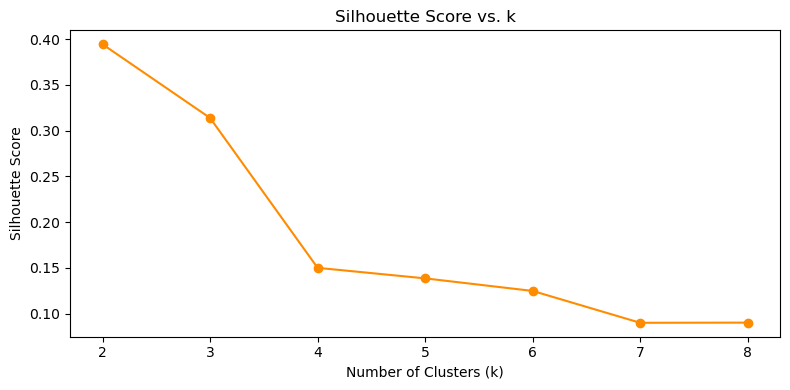

In [13]:
# Silhouette Curve
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), sil_list, marker='o', color='darkorange')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k')
plt.tight_layout()
plt.savefig('images/silhouette_curve.png', dpi=300)
plt.show()

In [14]:
# -------------------------------------------------------
# K-Means with best k (6 -- matches number of activities)
# -------------------------------------------------------
best_k = 6

km_best = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
km_labels = km_best.fit_predict(X_scaled)

print(f'K-Means fitted with k={best_k}')
print('Cluster sizes:', np.unique(km_labels, return_counts=True))

K-Means fitted with k=6
Cluster sizes: (array([0, 1, 2, 3, 4, 5]), array([2638,  307, 1920, 2449, 1338, 1647], dtype=int64))


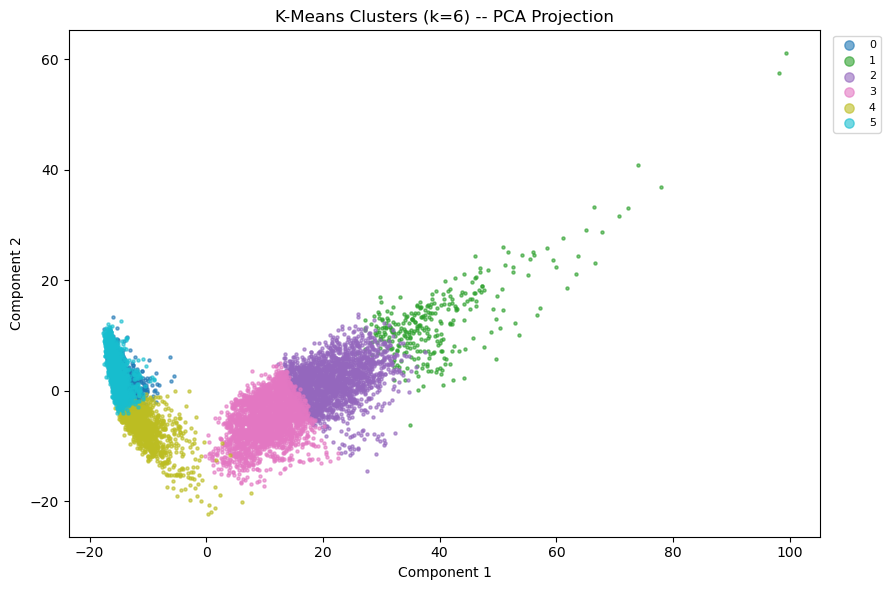

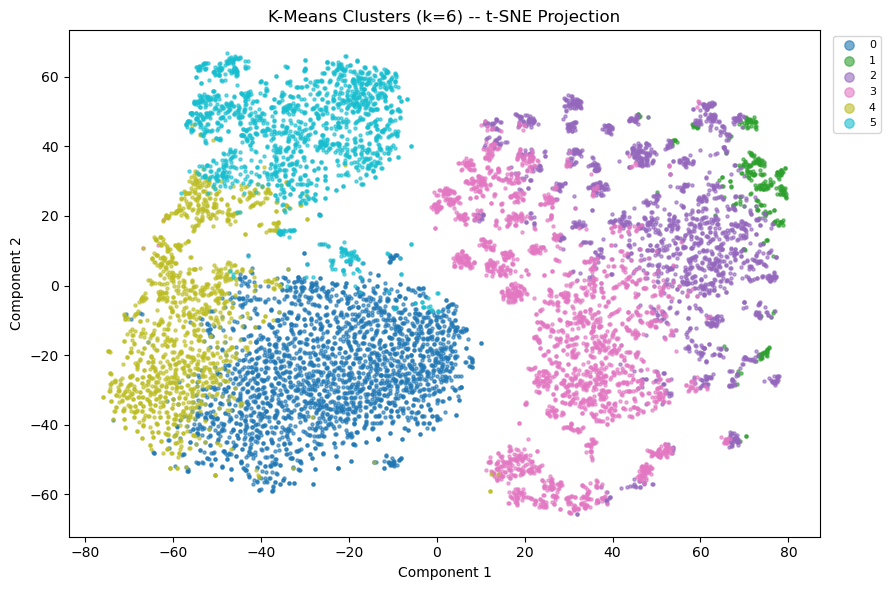

In [15]:
# K-Means visualizations
scatter_2d(X_pca2, km_labels,
           f'K-Means Clusters (k={best_k}) -- PCA Projection',
           'images/kmeans_pca.png')

scatter_2d(X_tsne, km_labels,
           f'K-Means Clusters (k={best_k}) -- t-SNE Projection',
           'images/kmeans_tsne.png')

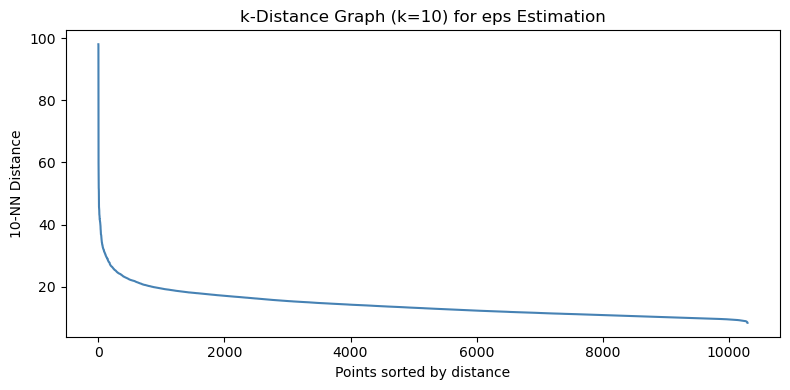

In [16]:
# -------------------------------------------------------
# DBSCAN -- tune eps using k-distance graph
# -------------------------------------------------------
from sklearn.neighbors import NearestNeighbors

# k-distance plot to estimate eps (k = minPts - 1)
min_pts = 10
nbrs = NearestNeighbors(n_neighbors=min_pts).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dist, color='steelblue')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_pts}-NN Distance')
plt.title(f'k-Distance Graph (k={min_pts}) for eps Estimation')
plt.tight_layout()
plt.savefig('images/kdistance_plot.png', dpi=300)
plt.show()

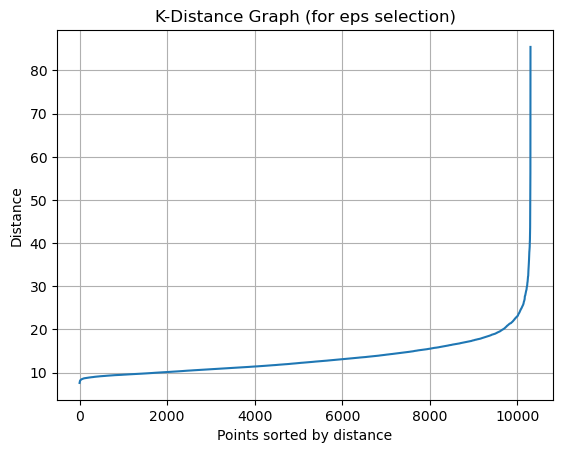

In [22]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Use the same data used for clustering (important!)
X = X_pca if 'X_pca' in globals() else X_scaled

# Choose k = min_samples (common choice: 4 or 5)
k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort distances
distances = np.sort(distances[:, k-1])

plt.figure()
plt.plot(distances)
plt.title("K-Distance Graph (for eps selection)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance")
plt.grid()
plt.show()

In [31]:
# DBSCAN with chosen eps
eps_val  = 25   # adjust after inspecting k-distance plot
min_samp = 10

dbscan = DBSCAN(eps=eps_val, min_samples=min_samp, n_jobs=-1)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = np.sum(db_labels == -1)

print(f'DBSCAN: eps={eps_val}, minPts={min_samp}')
print(f'  Clusters found : {n_clusters_db}')
print(f'  Noise points   : {n_noise_db} ({100*n_noise_db/len(db_labels):.1f}%)')

DBSCAN: eps=30, minPts=10
  Clusters found : 1
  Noise points   : 50 (0.5%)


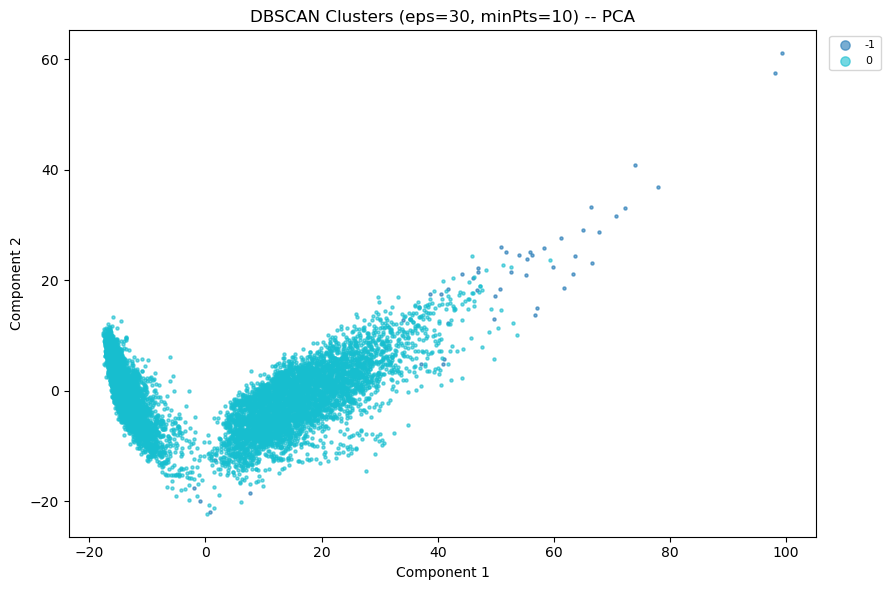

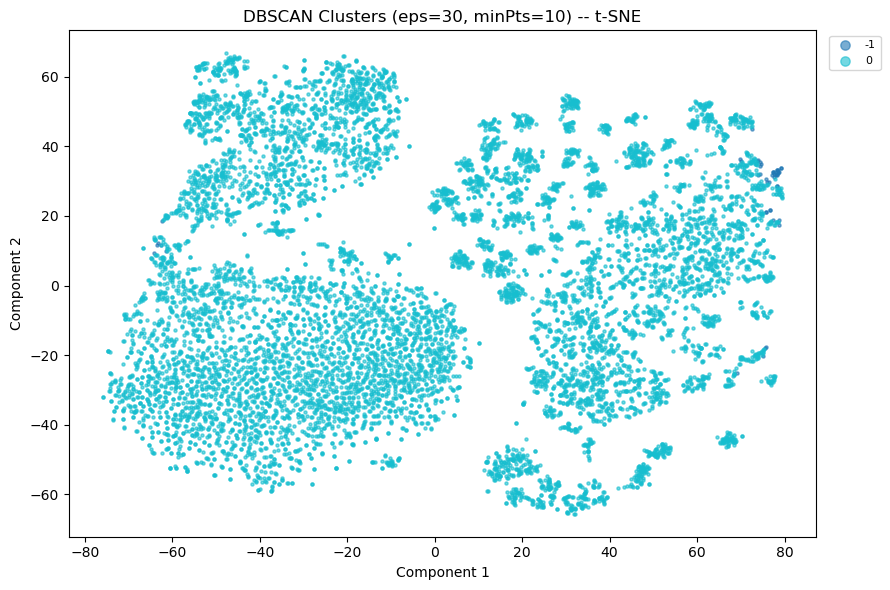

In [32]:
# DBSCAN visualizations
scatter_2d(X_pca2, db_labels,
           f'DBSCAN Clusters (eps={eps_val}, minPts={min_samp}) -- PCA',
           'images/dbscan_pca.png')

scatter_2d(X_tsne, db_labels,
           f'DBSCAN Clusters (eps={eps_val}, minPts={min_samp}) -- t-SNE',
           'images/dbscan_tsne.png')

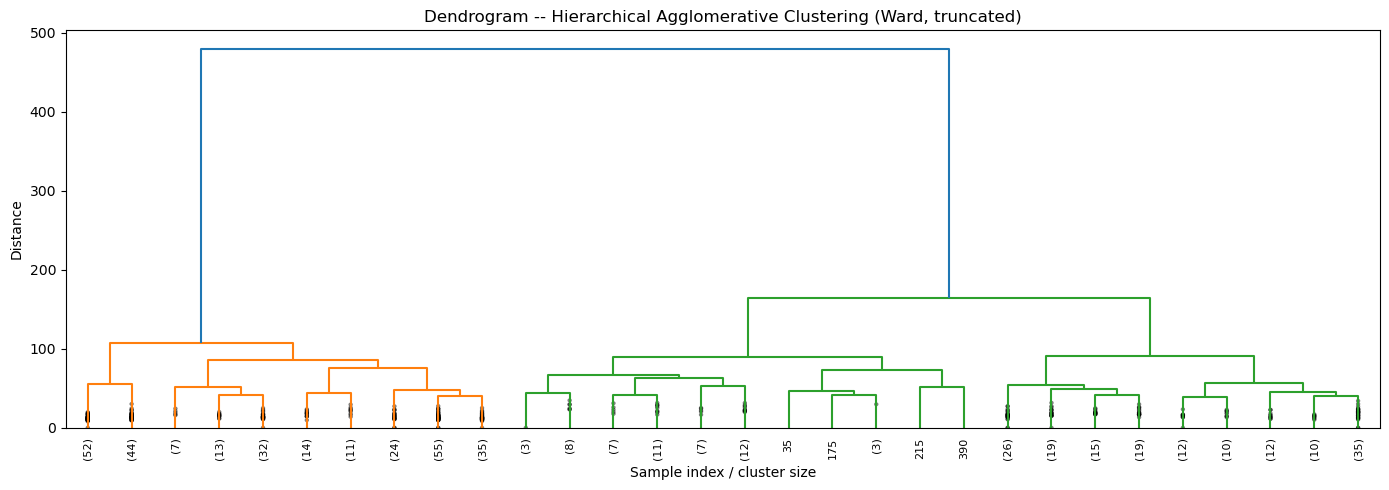

In [25]:
# -------------------------------------------------------
# Hierarchical Agglomerative Clustering
# -------------------------------------------------------
# Dendrogram (computed on a sample for readability)
X_dend_sample, _ = resample(X_scaled, y.values, n_samples=500, random_state=42)

Z = linkage(X_dend_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           show_contracted=True)
plt.title('Dendrogram -- Hierarchical Agglomerative Clustering (Ward, truncated)')
plt.xlabel('Sample index / cluster size')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('images/dendrogram.png', dpi=300)
plt.show()

In [26]:
# HAC on full dataset
hac = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hac_labels = hac.fit_predict(X_scaled)

print(f'HAC fitted with n_clusters={best_k}, linkage=ward')
print('Cluster sizes:', np.unique(hac_labels, return_counts=True))

HAC fitted with n_clusters=6, linkage=ward
Cluster sizes: (array([0, 1, 2, 3, 4, 5], dtype=int64), array([3208, 1313, 1206, 1834,  151, 2587], dtype=int64))


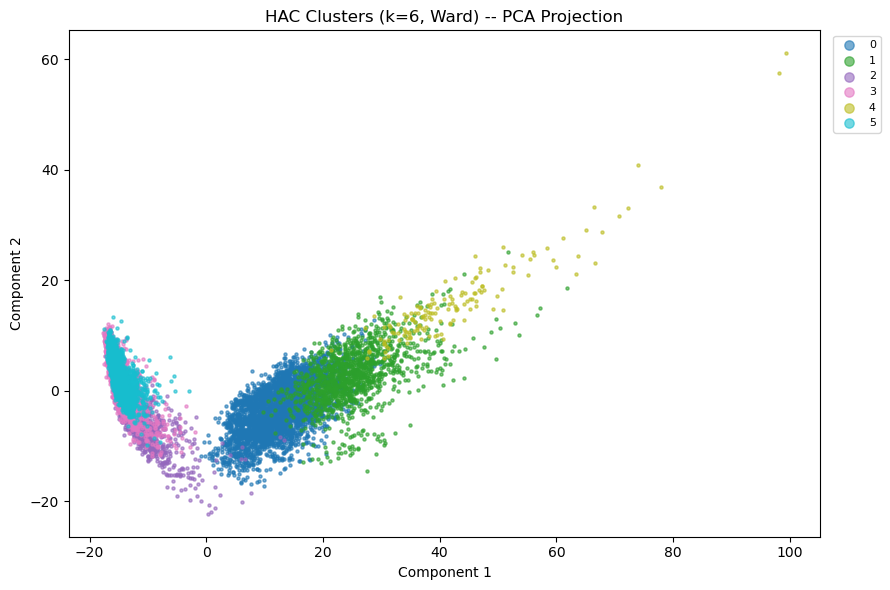

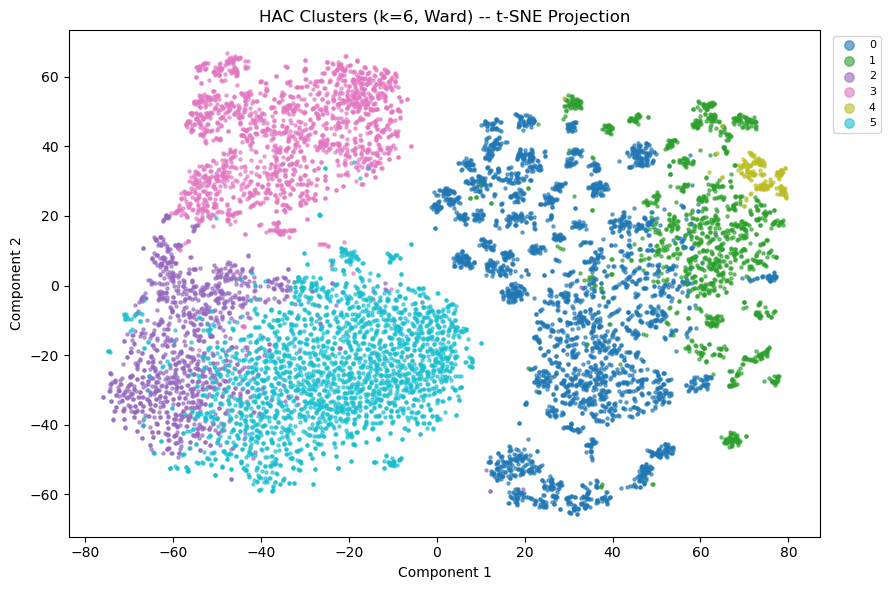

In [27]:
# HAC visualizations
scatter_2d(X_pca2, hac_labels,
           f'HAC Clusters (k={best_k}, Ward) -- PCA Projection',
           'images/hac_pca.png')

scatter_2d(X_tsne, hac_labels,
           f'HAC Clusters (k={best_k}, Ward) -- t-SNE Projection',
           'images/hac_tsne.png')

In [33]:
# -------------------------------------------------------
# Evaluation Metrics for all three algorithms
# -------------------------------------------------------
y_true = y.values

def evaluate(labels, y_true, X_data, name):
    # Internal metrics require at least 2 clusters and exclude noise
    mask = labels != -1
    X_m, l_m = X_data[mask], labels[mask]
    n_cls = len(set(l_m))

    sil = silhouette_score(X_m, l_m, sample_size=3000, random_state=42) if n_cls >= 2 else np.nan
    dbi = davies_bouldin_score(X_m, l_m)       if n_cls >= 2 else np.nan
    chi = calinski_harabasz_score(X_m, l_m)    if n_cls >= 2 else np.nan
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)

    print(f'{name}:')
    print(f'  Silhouette Score      : {sil:.4f}')
    print(f'  Davies-Bouldin Index  : {dbi:.4f}')
    print(f'  Calinski-Harabasz     : {chi:.2f}')
    print(f'  Adjusted Rand Index   : {ari:.4f}')
    print(f'  Normalized Mutual Info: {nmi:.4f}')
    print()
    return sil, dbi, chi, ari, nmi

km_metrics  = evaluate(km_labels,  y_true, X_scaled, 'K-Means')
db_metrics  = evaluate(db_labels,  y_true, X_scaled, 'DBSCAN')
hac_metrics = evaluate(hac_labels, y_true, X_scaled, 'HAC (Ward)')

K-Means:
  Silhouette Score      : 0.1096
  Davies-Bouldin Index  : 2.3836
  Calinski-Harabasz     : 2556.54
  Adjusted Rand Index   : 0.4196
  Normalized Mutual Info: 0.5593

DBSCAN:
  Silhouette Score      : nan
  Davies-Bouldin Index  : nan
  Calinski-Harabasz     : nan
  Adjusted Rand Index   : 0.0006
  Normalized Mutual Info: 0.0076

HAC (Ward):
  Silhouette Score      : 0.1139
  Davies-Bouldin Index  : 2.4820
  Calinski-Harabasz     : 2349.67
  Adjusted Rand Index   : 0.4599
  Normalized Mutual Info: 0.6015



In [29]:
# Metrics summary table
metrics_df = pd.DataFrame(
    [km_metrics, db_metrics, hac_metrics],
    columns=['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'ARI', 'NMI'],
    index=['K-Means', 'DBSCAN', 'HAC (Ward)']
)
print('Clustering Evaluation Metrics:')
print(metrics_df.round(4).to_string())

Clustering Evaluation Metrics:
            Silhouette  Davies-Bouldin  Calinski-Harabasz     ARI     NMI
K-Means         0.1096          2.3836          2556.5419  0.4196  0.5593
DBSCAN             NaN             NaN                NaN  0.0019  0.0163
HAC (Ward)      0.1139          2.4820          2349.6677  0.4599  0.6015


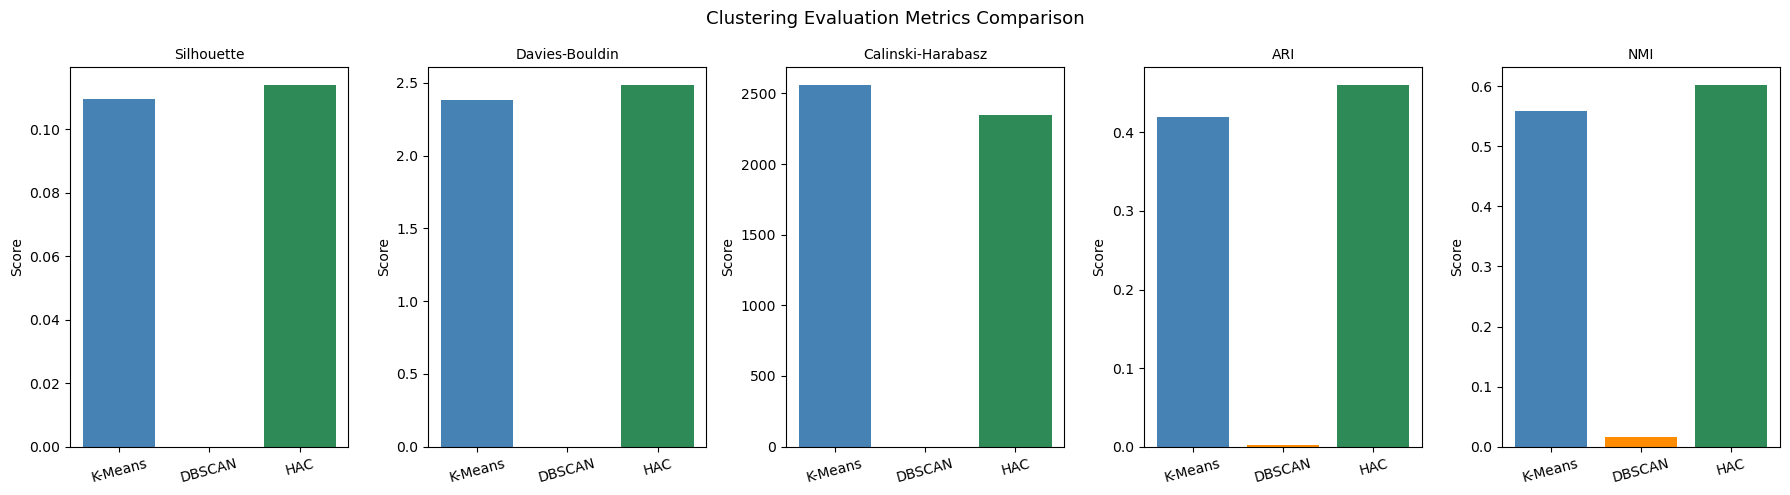

In [30]:
# Bar plot of evaluation metrics
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
metric_names = ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'ARI', 'NMI']
algo_names   = ['K-Means', 'DBSCAN', 'HAC']
colors_bar   = ['steelblue', 'darkorange', 'seagreen']

for i, (ax, mname) in enumerate(zip(axes, metric_names)):
    vals = [km_metrics[i], db_metrics[i], hac_metrics[i]]
    ax.bar(algo_names, vals, color=colors_bar)
    ax.set_title(mname, fontsize=10)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Clustering Evaluation Metrics Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('images/metrics_comparison.png', dpi=300)
plt.show()

In [34]:
# Full Summary
print('=' * 65)
print('          EXPERIMENT 9 - FULL SUMMARY')
print('=' * 65)
print(f'Dataset          : HAR (10299 samples, 561 features)')
print(f'Best K-Means k   : {best_k}')
print(f'DBSCAN eps       : {eps_val}  minPts: {min_samp}')
print(f'DBSCAN clusters  : {n_clusters_db}  Noise: {n_noise_db}')
print(f'HAC linkage      : Ward  n_clusters: {best_k}')
print()
print(metrics_df.round(4).to_string())
print('=' * 65)

          EXPERIMENT 9 - FULL SUMMARY
Dataset          : HAR (10299 samples, 561 features)
Best K-Means k   : 6
DBSCAN eps       : 2.5  minPts: 10
DBSCAN clusters  : 0  Noise: 10299
HAC linkage      : Ward  n_clusters: 6

            Silhouette  Davies-Bouldin  Calinski-Harabasz     ARI     NMI
K-Means         0.1096          2.3836          2556.5419  0.4196  0.5593
DBSCAN             NaN             NaN                NaN  0.0000  0.0000
HAC (Ward)      0.1139          2.4820          2349.6677  0.4599  0.6015
